# Batch Temperature Map Inpainting — 2nd Action
### Run cells in order: 1 → 2 → 3 → 4 → 5
### Inputs: `window_1_block_avg.csv` and `window_2_block_avg.csv` (from effusion_hole_block_avg_temperature_1st_action)
### Outputs saved to: `.../half_domain_temperature/effusion_hole_block_avg_temperature_2nd_action/`

In [1]:
# ══════════════════════════════════════════════════════════════════
# CELL 1 — CONFIGURATION
# ══════════════════════════════════════════════════════════════════

ROOT_DIR       = r"D:\FCAI\plain_coupon\infared_data"
REFERENCE_CASE = "cr_500_phi_09"

# Subfolder inside each case that holds the input CSV files
# Input  : time_average/average_temperature/half_domain_temperature/effusion_hole_block_avg_temperature_1st_action/<input_csv>
# Output : time_average/average_temperature/half_domain_temperature/effusion_hole_block_avg_temperature_2nd_action/<output_csv>
DATA_SUBPATH    = r"time_average\average_temperature\half_domain_temperature\effusion_hole_block_avg_temperature_1st_action"
OUT_BASEPATH    = r"time_average\average_temperature\half_domain_temperature"   # parent folder for output
OUT_SUBDIR      = "effusion_hole_block_avg_temperature_2nd_action"

USE_GP              = True
GP_MAX_TRAINING_PTS = 2000
GP_CONTEXT_DILATION = 20

# ── Window definitions — inputs are the already-inpainted CSVs ───
# Regions are drawn interactively in Cell 3 (no pre-defined masks)
WINDOWS = [
    {
        "input_csv"     : "window_1_block_avg.csv",
        "output_csv"    : "window_1_block_avg.csv",
        "png_result"    : "window_1_block_avg.png",
        "regions"       : [],   # empty — draw in Cell 3
    },
    {
        "input_csv"     : "window_2_block_avg.csv",
        "output_csv"    : "window_2_block_avg.csv",
        "png_result"    : "window_2_block_avg.png",
        "regions"       : [],   # empty — draw in Cell 3
    },
]

print("Config loaded.")
for w in WINDOWS:
    print(f"  {w['input_csv']}  →  {OUT_SUBDIR}/{w['output_csv']}")
print(f"  Data path : .../<case>/{DATA_SUBPATH}/")

Config loaded.
  window_1_block_avg.csv  →  effusion_hole_block_avg_temperature_2nd_action/window_1_block_avg.csv
  window_2_block_avg.csv  →  effusion_hole_block_avg_temperature_2nd_action/window_2_block_avg.csv
  Data path : .../<case>/time_average\average_temperature\half_domain_temperature\effusion_hole_block_avg_temperature_1st_action/


In [2]:
# ══════════════════════════════════════════════════════════════════
# CELL 2 — IMPORTS & HELPERS
# ══════════════════════════════════════════════════════════════════
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.path import Path as MplPath
from scipy.ndimage import binary_dilation
from skimage.restoration import inpaint_biharmonic
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, ConstantKernel
from pathlib import Path
import traceback

# ── CSV loader (reads full grid — no half-domain slicing) ────────
# The input files are already half-domain inpainted CSVs,
# so we load them as-is without the [:N//2] crop.
def load_csv(csv_path):
    raw   = Path(csv_path).read_text(encoding="utf-8", errors="replace")
    lines = [l.strip() for l in raw.splitlines() if l.strip()]
    col_counts = [len(l.split(",")) for l in lines]
    max_cols   = max(col_counts)
    data_lines = [l for l, c in zip(lines, col_counts) if c >= max_cols * 0.5]
    return np.array(
        [[float(v) for v in row.split(",")] for row in data_lines],
        dtype=np.float64
    )

# ── Mask builder ─────────────────────────────────────────────────
def build_mask(data_shape, regions):
    mask   = np.zeros(data_shape, dtype=bool)
    nr, nc = data_shape
    for reg in regions:
        if reg["type"] == "rect":
            r0 = max(0, reg["row_start"]);  r1 = min(nr-1, reg["row_end"])
            c0 = max(0, reg["col_start"]);  c1 = min(nc-1, reg["col_end"])
            mask[r0:r1+1, c0:c1+1] = True
        elif reg["type"] == "polygon":
            path   = MplPath(reg["vertices"])
            ci, ri = np.meshgrid(np.arange(nc), np.arange(nr))
            mask  |= path.contains_points(
                np.column_stack([ci.ravel(), ri.ravel()])
            ).reshape(nr, nc)
    return mask

# ── Case discovery ───────────────────────────────────────────────
def discover_cases(root_dir, data_subpath, input_csv):
    return sorted(
        [d for d in Path(root_dir).iterdir()
         if d.is_dir() and (d / data_subpath / input_csv).exists()]
    )

# ── Inpainting ───────────────────────────────────────────────────
def gp_inpaint(data, mask):
    result     = data.copy()
    rows, cols = np.where(mask)
    dilated    = binary_dilation(mask, iterations=GP_CONTEXT_DILATION)
    cr, cc     = np.where(dilated & ~mask)
    if len(cr) < 10:
        print("      [GP] context too small → biharmonic")
        return _bih(data, mask)
    if len(cr) > GP_MAX_TRAINING_PTS:
        idx    = np.random.choice(len(cr), GP_MAX_TRAINING_PTS, replace=False)
        cr, cc = cr[idx], cc[idx]
    X  = np.column_stack([cr, cc]).astype(float)
    y  = data[cr, cc]
    sc = float(max(data.shape))
    k  = (ConstantKernel(np.var(y), (1e-3, 1e6)) *
          RBF(0.1, (1e-3, 10.0)) +
          WhiteKernel(1.0, (1e-5, 1e3)))
    gp = GaussianProcessRegressor(kernel=k, n_restarts_optimizer=3, normalize_y=True)
    gp.fit(X / sc, y)
    yp, ys = gp.predict(
        np.column_stack([rows, cols]).astype(float) / sc, return_std=True)
    result[rows, cols] = yp
    print(f"      [GP] σ mean={ys.mean():.3f} K  max={ys.max():.3f} K")
    return result

def _bih(data, mask):
    return inpaint_biharmonic(data, mask, channel_axis=None)

def run_inpaint(data, mask):
    n = int(mask.sum())
    if USE_GP and n <= 5000:
        return gp_inpaint(data, mask), "GP"
    if USE_GP:
        print(f"      GP skipped ({n} px > 5000) → biharmonic")
    return _bih(data, mask), "Biharmonic"

# ── Plot helper ──────────────────────────────────────────────────
def save_result_png(data, result, mask, path, name, win_label, method):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    vmin, vmax = data.min(), data.max()
    axes[0].imshow(data, cmap="inferno", vmin=vmin, vmax=vmax, origin="upper", aspect="auto")
    if mask.any():
        rgba = np.zeros((*data.shape, 4))
        rgba[mask] = [1, 0, 0, 0.45]
        axes[0].imshow(rgba, origin="upper", aspect="auto")
    axes[0].set_title("Input (masked regions red)", fontsize=9)
    axes[0].set_xlabel("Column"); axes[0].set_ylabel("Row")
    im = axes[1].imshow(result, cmap="inferno", vmin=vmin, vmax=vmax, origin="upper", aspect="auto")
    axes[1].set_title(f"Result ({method})", fontsize=9)
    axes[1].set_xlabel("Column"); axes[1].set_ylabel("Row")
    fig.colorbar(im, ax=axes, label="T [K]", shrink=0.8)
    fig.suptitle(f"{name} — {win_label}", fontsize=11)
    plt.tight_layout()
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.close(fig)

print("Helpers ready.")

Helpers ready.


In [4]:
# ══════════════════════════════════════════════════════════════════
# CELL 3 — INTERACTIVE REGION SELECTOR
#
# Set SELECTOR_WINDOW = 0 (window_1) or 1 (window_2), then run.
# The reference image is loaded from REFERENCE_CASE.
# Keys inside the popup:
#   R  → Rectangle  (click 2 corners)
#   P  → Polygon    (click vertices, Enter to close)
#   D  → Undo last
#   C  → Clear all
#   Q  → Confirm & close
# ══════════════════════════════════════════════════════════════════
SELECTOR_WINDOW = 1   # 0 = window_1_inpainted,  1 = window_2_inpainted

try:
    matplotlib.use("TkAgg")
except Exception:
    pass

win_cfg   = WINDOWS[SELECTOR_WINDOW]
win_label = win_cfg["input_csv"].replace(".csv", "")
ref_csv   = Path(ROOT_DIR) / REFERENCE_CASE / DATA_SUBPATH / win_cfg["input_csv"]
ref_data  = load_csv(ref_csv)
print(f"Reference : {REFERENCE_CASE} / {win_cfg['input_csv']}")
print(f"Shape     : {ref_data.shape}   T=[{ref_data.min():.1f}, {ref_data.max():.1f}] K")

sel_masks = []   # always start empty — draw all regions interactively
print("Canvas ready. Use R (rectangle), P (polygon), D (undo), C (clear), Q (done).")


def _redraw(fig, ax, data, rmasks):
    ax.cla()
    ax.imshow(data, cmap="inferno", origin="upper", aspect="auto")
    combined = np.zeros(data.shape, dtype=bool)
    for m in rmasks:
        combined |= m
    if combined.any():
        rgba = np.zeros((*data.shape, 4))
        rgba[combined] = [1, 0, 0, 0.45]
        ax.imshow(rgba, origin="upper", aspect="auto")
    ax.set_title(
        f"{win_label}  |  Regions: {len(rmasks)}  Masked: {int(combined.sum())} px\n"
        "[R] Rectangle   [P] Polygon   [D] Undo   [C] Clear   [Q] Done",
        fontsize=9
    )
    ax.set_xlabel("Column"); ax.set_ylabel("Row")
    fig.canvas.draw()

def _mk_rect(p1, p2, shape):
    nr, nc = shape
    c0, c1 = sorted([int(round(p1[0])), int(round(p2[0]))])
    r0, r1 = sorted([int(round(p1[1])), int(round(p2[1]))])
    c0=max(0,c0); c1=min(nc-1,c1); r0=max(0,r0); r1=min(nr-1,r1)
    m = np.zeros(shape, dtype=bool)
    m[r0:r1+1, c0:c1+1] = True
    return m, r0, r1, c0, c1

def _mk_poly(pts, shape):
    if len(pts) < 3:
        print("  Need >= 3 points"); return None
    nr, nc = shape
    ci, ri = np.meshgrid(np.arange(nc), np.arange(nr))
    return MplPath(pts).contains_points(
        np.column_stack([ci.ravel(), ri.ravel()])
    ).reshape(nr, nc)

plt.close("all")
fig, ax = plt.subplots(figsize=(11, 5))
try:
    fig.canvas.manager.set_window_title(f"Region Selector — {REFERENCE_CASE} / {win_label}")
except Exception:
    pass
_redraw(fig, ax, ref_data, sel_masks)

def on_key(event):
    key = (event.key or "").lower()
    if key == "r":
        ax.set_title("RECTANGLE: click 2 corners", color="cyan", fontsize=10)
        fig.canvas.draw()
        pts = fig.ginput(2, timeout=60, show_clicks=True)
        if len(pts) == 2:
            m, r0, r1, c0, c1 = _mk_rect(pts[0], pts[1], ref_data.shape)
            sel_masks.append(m)
            print(f"  + Rectangle rows[{r0}:{r1}] cols[{c0}:{c1}]  ({m.sum()} px)")
        else:
            print("  Rectangle cancelled.")
        _redraw(fig, ax, ref_data, sel_masks)
    elif key == "p":
        ax.set_title("POLYGON: click vertices, Enter to close", color="cyan", fontsize=10)
        fig.canvas.draw()
        pts = fig.ginput(-1, timeout=120, show_clicks=True)
        if pts:
            m = _mk_poly(pts, ref_data.shape)
            if m is not None:
                sel_masks.append(m)
                print(f"  + Polygon {len(pts)} vertices  ({m.sum()} px)")
        else:
            print("  Polygon cancelled.")
        _redraw(fig, ax, ref_data, sel_masks)
    elif key == "d":
        if sel_masks:
            n = int(sel_masks.pop().sum())
            print(f"  - Removed last region ({n} px). Remaining: {len(sel_masks)}")
            _redraw(fig, ax, ref_data, sel_masks)
        else:
            print("  Nothing to undo.")
    elif key == "c":
        sel_masks.clear()
        print("  All regions cleared.")
        _redraw(fig, ax, ref_data, sel_masks)
    elif key == "q":
        plt.close(fig)
        combined = np.zeros(ref_data.shape, dtype=bool)
        for m in sel_masks:
            combined |= m
        WINDOWS[SELECTOR_WINDOW]["_override_mask"] = combined
        print(f"\nFinalised {win_label}: {len(sel_masks)} region(s), "
              f"{int(combined.sum())} px total.")
        print("Run Cell 4 to preview, then Cell 5 to batch-process.")

fig.canvas.mpl_connect("key_press_event", on_key)
plt.show(block=True)

Reference : cr_500_phi_09 / window_2_block_avg.csv
Shape     : (75, 150)   T=[217.9, 550.0] K
Canvas ready. Use R (rectangle), P (polygon), D (undo), C (clear), Q (done).
  + Rectangle rows[13:28] cols[0:7]  (128 px)
  - Removed last region (128 px). Remaining: 0
  + Rectangle rows[11:28] cols[0:10]  (198 px)

Finalised window_2_block_avg: 1 region(s), 198 px total.
Run Cell 4 to preview, then Cell 5 to batch-process.


  window_1_block_avg: 288 px masked
  window_2_block_avg: 198 px masked


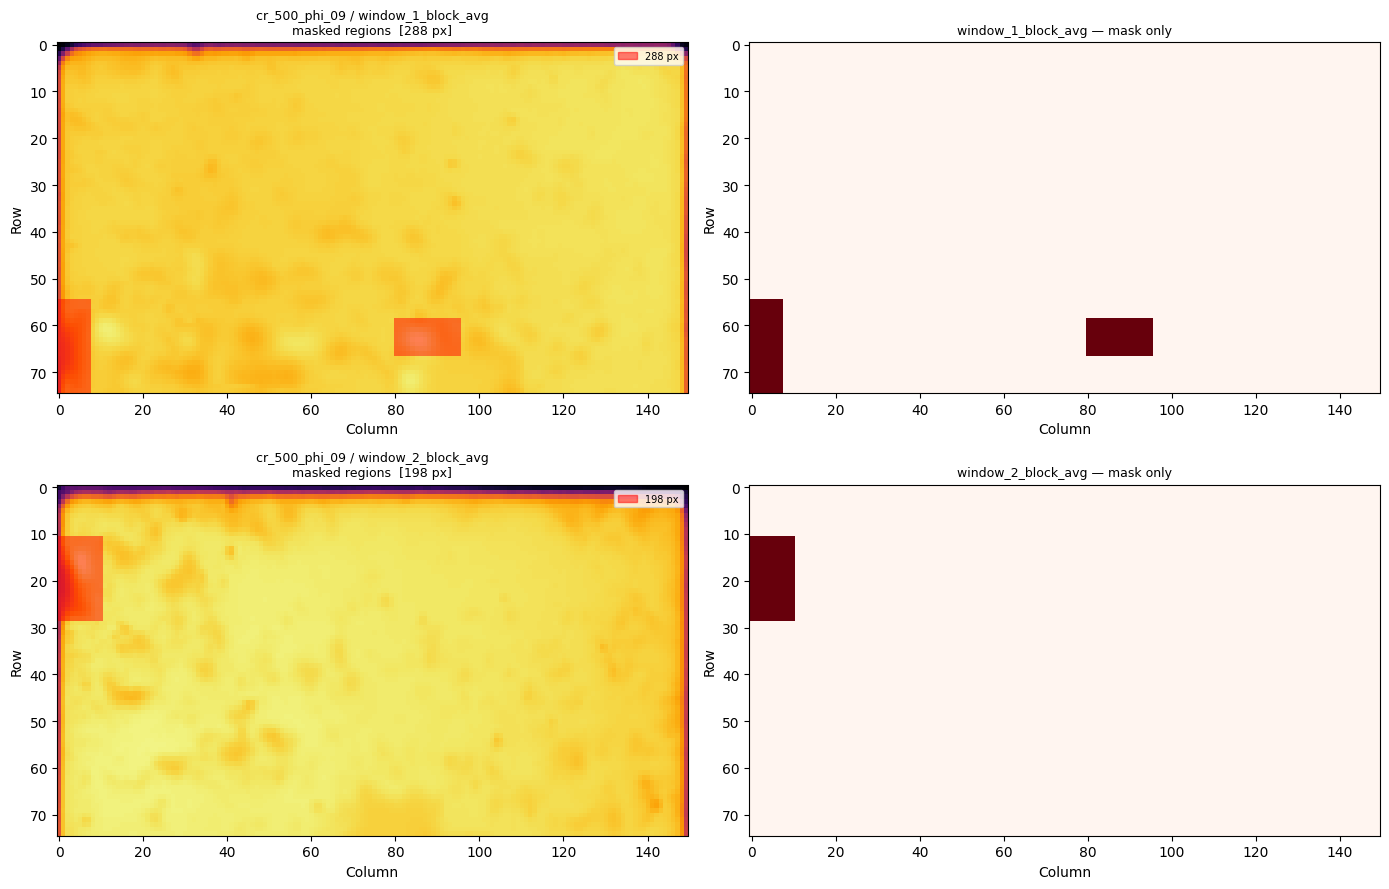

If both masks look correct → run Cell 5.
To adjust: re-run Cell 3 with SELECTOR_WINDOW=0 or 1, then re-run this cell.


In [5]:
# ══════════════════════════════════════════════════════════════════
# CELL 4 — PREVIEW MASKS FOR BOTH WINDOWS ON REFERENCE CASE
# ══════════════════════════════════════════════════════════════════
%matplotlib inline

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

for row_idx, win_cfg in enumerate(WINDOWS):
    win_label = win_cfg["input_csv"].replace(".csv", "")
    ref_csv   = Path(ROOT_DIR) / REFERENCE_CASE / DATA_SUBPATH / win_cfg["input_csv"]

    try:
        d = load_csv(ref_csv)
    except Exception as e:
        print(f"  Could not load {win_cfg['input_csv']}: {e}")
        continue

    if "_override_mask" in win_cfg:
        om   = win_cfg["_override_mask"]
        mask = np.zeros(d.shape, dtype=bool)
        sr   = min(om.shape[0], d.shape[0]); sc = min(om.shape[1], d.shape[1])
        mask[:sr, :sc] = om[:sr, :sc]
    else:
        mask = build_mask(d.shape, win_cfg["regions"])

    vmin, vmax = d.min(), d.max()

    ax = axes[row_idx, 0]
    ax.imshow(d, cmap="inferno", vmin=vmin, vmax=vmax, origin="upper", aspect="auto")
    if mask.any():
        rgba = np.zeros((*d.shape, 4))
        rgba[mask] = [1, 0, 0, 0.5]
        ax.imshow(rgba, origin="upper", aspect="auto")
    ax.set_title(f"{REFERENCE_CASE} / {win_label}\nmasked regions  [{mask.sum()} px]", fontsize=9)
    ax.set_xlabel("Column"); ax.set_ylabel("Row")
    ax.legend(
        handles=[mpatches.Patch(color="red", alpha=0.5, label=f"{mask.sum()} px")],
        loc="upper right", fontsize=7
    )

    axes[row_idx, 1].imshow(mask, cmap="Reds", origin="upper", aspect="auto")
    axes[row_idx, 1].set_title(f"{win_label} — mask only", fontsize=9)
    axes[row_idx, 1].set_xlabel("Column"); axes[row_idx, 1].set_ylabel("Row")

    print(f"  {win_label}: {mask.sum()} px masked")

plt.tight_layout()
plt.show()
print("If both masks look correct → run Cell 5.")
print("To adjust: re-run Cell 3 with SELECTOR_WINDOW=0 or 1, then re-run this cell.")

In [6]:
# ══════════════════════════════════════════════════════════════════
# CELL 5 — PARALLEL BATCH PROCESSING  (all cases × all windows)
#
# Reads  : .../average_temperature/window_1_inpainted.csv
#          .../average_temperature/window_2_inpainted.csv
# Writes : .../average_temperature/effusion_hole_block_avg_temperature/
#              window_1_block_avg.csv  +  window_1_block_avg.png
#              window_2_block_avg.csv  +  window_2_block_avg.png
#
# Uses joblib (Loky backend) — Jupyter + Windows safe, no
# "if __name__ == '__main__'" guard needed.
# N_WORKERS controls parallelism — -1 = use all logical cores.
# ══════════════════════════════════════════════════════════════════
%matplotlib inline
import os
import numpy as np
import pandas as pd
from pathlib import Path
from joblib import Parallel, delayed

N_WORKERS = 8   # -1 = all cores; 8 = cap at 8; 1 = serial (for debugging)

# ── Worker function ───────────────────────────────────────────────
# joblib serialises this with cloudpickle, which handles closures and
# numpy arrays cleanly — no manual pickling or shared-state issues.
def _process_one(job):
    import numpy as np
    import pandas as pd
    import matplotlib
    matplotlib.use("Agg")          # non-interactive — safe in subprocesses
    import matplotlib.pyplot as plt
    from pathlib import Path
    from scipy.ndimage import binary_dilation
    from skimage.restoration import inpaint_biharmonic
    from sklearn.gaussian_process import GaussianProcessRegressor
    from sklearn.gaussian_process.kernels import RBF, WhiteKernel, ConstantKernel
    import traceback

    name       = job["name"]
    win_label  = job["win_label"]
    csv_in     = Path(job["csv_in"])
    out_dir    = Path(job["out_dir"])
    out_dir.mkdir(parents=True, exist_ok=True)
    output_csv = out_dir / job["output_csv"]
    output_png = out_dir / job["png_result"]
    mask_arr   = job["mask"]
    use_gp     = job["use_gp"]
    gp_max_pts = job["gp_max_pts"]
    gp_dilation= job["gp_dilation"]

    log = []

    # ── Inpainting helpers ────────────────────────────────────────
    def _bih(data, mask):
        return inpaint_biharmonic(data, mask, channel_axis=None)

    def _gp(data, mask):
        result     = data.copy()
        rows, cols = np.where(mask)
        dilated    = binary_dilation(mask, iterations=gp_dilation)
        cr, cc     = np.where(dilated & ~mask)
        if len(cr) < 10:
            log.append("      [GP] context too small → biharmonic")
            return _bih(data, mask)
        if len(cr) > gp_max_pts:
            idx    = np.random.choice(len(cr), gp_max_pts, replace=False)
            cr, cc = cr[idx], cc[idx]
        X  = np.column_stack([cr, cc]).astype(float)
        y  = data[cr, cc]
        sc = float(max(data.shape))
        k  = (ConstantKernel(np.var(y), (1e-3, 1e6)) *
              RBF(0.1, (1e-3, 10.0)) +
              WhiteKernel(1.0, (1e-5, 1e3)))
        gp = GaussianProcessRegressor(kernel=k, n_restarts_optimizer=3, normalize_y=True)
        gp.fit(X / sc, y)
        yp, ys = gp.predict(
            np.column_stack([rows, cols]).astype(float) / sc, return_std=True)
        result[rows, cols] = yp
        log.append(f"      [GP] σ mean={ys.mean():.3f} K  max={ys.max():.3f} K")
        return result

    def _run_inpaint(data, mask):
        n = int(mask.sum())
        if use_gp and n <= 5000:
            return _gp(data, mask), "GP"
        if use_gp:
            log.append(f"      GP skipped ({n} px > 5000) → biharmonic")
        return _bih(data, mask), "Biharmonic"

    # ── Main work ─────────────────────────────────────────────────
    try:
        # Load CSV
        raw        = csv_in.read_text(encoding="utf-8", errors="replace")
        lines      = [l.strip() for l in raw.splitlines() if l.strip()]
        col_counts = [len(l.split(",")) for l in lines]
        max_cols   = max(col_counts)
        data_lines = [l for l, c in zip(lines, col_counts) if c >= max_cols * 0.5]
        data       = np.array(
            [[float(v) for v in row.split(",")] for row in data_lines],
            dtype=np.float64
        )
        log.append(f"    shape={data.shape}  T=[{data.min():.1f}, {data.max():.1f}] K")

        # Clip mask to actual data shape
        mask = np.zeros(data.shape, dtype=bool)
        sr   = min(mask_arr.shape[0], data.shape[0])
        sc   = min(mask_arr.shape[1], data.shape[1])
        mask[:sr, :sc] = mask_arr[:sr, :sc]
        log.append(f"    mask={mask.sum()} px  ({100*mask.sum()/mask.size:.1f}%)")

        # Inpaint
        result, method = _run_inpaint(data, mask)
        log.append(f"    method={method}")

        # Save CSV
        pd.DataFrame(result).to_csv(output_csv, header=False, index=False)
        log.append(f"    CSV  → {output_csv}")

        # Save PNG
        vmin, vmax = data.min(), data.max()
        fig, axes = plt.subplots(1, 2, figsize=(13, 4))
        axes[0].imshow(data, cmap="inferno", vmin=vmin, vmax=vmax,
                       origin="upper", aspect="auto")
        if mask.any():
            rgba = np.zeros((*data.shape, 4))
            rgba[mask] = [1, 0, 0, 0.45]
            axes[0].imshow(rgba, origin="upper", aspect="auto")
        axes[0].set_title("Input (masked regions red)", fontsize=9)
        axes[0].set_xlabel("Column"); axes[0].set_ylabel("Row")
        im = axes[1].imshow(result, cmap="inferno", vmin=vmin, vmax=vmax,
                            origin="upper", aspect="auto")
        axes[1].set_title(f"Result ({method})", fontsize=9)
        axes[1].set_xlabel("Column"); axes[1].set_ylabel("Row")
        fig.colorbar(im, ax=axes, label="T [K]", shrink=0.8)
        fig.suptitle(f"{name} — {win_label}", fontsize=11)
        plt.tight_layout()
        plt.savefig(output_png, dpi=150, bbox_inches="tight")
        plt.close(fig)
        log.append(f"    PNG  → {output_png}")

        return (name, win_label, "OK", method, "\n".join(log))

    except Exception as e:
        log.append(f"    ERROR: {e}")
        log.append(traceback.format_exc())
        return (name, win_label, "FAILED", str(e), "\n".join(log))


# ── Build job list ────────────────────────────────────────────────
jobs = []
for win_cfg in WINDOWS:
    win_label = win_cfg["input_csv"].replace(".csv", "")
    cases     = discover_cases(ROOT_DIR, DATA_SUBPATH, win_cfg["input_csv"])
    print(f"  {win_label}: {len(cases)} cases found")

    # Resolve mask once per window — shared across all cases for that window
    if "_override_mask" in win_cfg:
        shared_mask = win_cfg["_override_mask"]
    else:
        ref_csv     = Path(ROOT_DIR) / REFERENCE_CASE / DATA_SUBPATH / win_cfg["input_csv"]
        ref_data    = load_csv(ref_csv)
        shared_mask = build_mask(ref_data.shape, win_cfg["regions"])

    for case_dir in cases:
        jobs.append({
            "name"       : case_dir.name,
            "win_label"  : win_label,
            "csv_in"     : str(case_dir / DATA_SUBPATH / win_cfg["input_csv"]),
            "out_dir"    : str(case_dir / OUT_BASEPATH / OUT_SUBDIR),
            "output_csv" : win_cfg["output_csv"],
            "png_result" : win_cfg["png_result"],
            "mask"       : shared_mask,
            "use_gp"     : USE_GP,
            "gp_max_pts" : GP_MAX_TRAINING_PTS,
            "gp_dilation": GP_CONTEXT_DILATION,
        })

n_workers = N_WORKERS if N_WORKERS != -1 else os.cpu_count()
print(f"\nDispatching {len(jobs)} jobs across {n_workers} workers...\n")

# ── Run in parallel (Loky backend — Jupyter + Windows safe) ──────
# verbose=10 prints a progress line as each job completes
results = Parallel(n_jobs=N_WORKERS, backend="loky", verbose=10)(
    delayed(_process_one)(job) for job in jobs
)

# ── Print per-job logs & collect summary ─────────────────────────
grand_log = []
for name, win_label, status, note, logs in results:
    grand_log.append((name, win_label, status, note))
    mark = "✓" if status == "OK" else "✗"
    print(f"\n{mark} [{name}] {win_label}")
    print(logs)

# ── Grand summary ─────────────────────────────────────────────────
ok     = [r for r in grand_log if r[2] == "OK"]
failed = [r for r in grand_log if r[2] == "FAILED"]
print("\n" + "=" * 62)
print(f"ALL DONE — {len(ok)}/{len(grand_log)} succeeded"
      + (f",  {len(failed)} failed" if failed else ""))
if failed:
    print("\nFailed jobs:")
    for name, win, status, note in grand_log:
        if status == "FAILED":
            print(f"  ✗  {name}  /  {win}  —  {note}")
print("=" * 62)

  window_1_block_avg: 15 cases found
  window_2_block_avg: 15 cases found

Dispatching 30 jobs across 8 workers...



[Parallel(n_jobs=8)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done   2 tasks      | elapsed:  1.1min
[Parallel(n_jobs=8)]: Done   9 tasks      | elapsed:  1.9min
[Parallel(n_jobs=8)]: Done  19 out of  30 | elapsed:  2.6min remaining:  1.5min
[Parallel(n_jobs=8)]: Done  23 out of  30 | elapsed:  2.8min remaining:   51.8s
[Parallel(n_jobs=8)]: Done  27 out of  30 | elapsed:  3.0min remaining:   19.6s



✓ [cr_1400_phi_085] window_1_block_avg
    shape=(75, 150)  T=[206.6, 447.3] K
    mask=288 px  (2.6%)
      [GP] σ mean=1.906 K  max=2.971 K
    method=GP
    CSV  → D:\FCAI\plain_coupon\infared_data\cr_1400_phi_085\time_average\average_temperature\half_domain_temperature\effusion_hole_block_avg_temperature_2nd_action\window_1_block_avg.csv
    PNG  → D:\FCAI\plain_coupon\infared_data\cr_1400_phi_085\time_average\average_temperature\half_domain_temperature\effusion_hole_block_avg_temperature_2nd_action\window_1_block_avg.png

✓ [cr_1400_phi_09] window_1_block_avg
    shape=(75, 150)  T=[207.8, 488.2] K
    mask=288 px  (2.6%)
      [GP] σ mean=1.983 K  max=3.112 K
    method=GP
    CSV  → D:\FCAI\plain_coupon\infared_data\cr_1400_phi_09\time_average\average_temperature\half_domain_temperature\effusion_hole_block_avg_temperature_2nd_action\window_1_block_avg.csv
    PNG  → D:\FCAI\plain_coupon\infared_data\cr_1400_phi_09\time_average\average_temperature\half_domain_temperature\effusio

[Parallel(n_jobs=8)]: Done  30 out of  30 | elapsed:  3.1min finished


In [7]:
# ══════════════════════════════════════════════════════════════════
# CELL 6 — PARALLEL ANISOTROPIC DIFFUSION SMOOTHING (Perona-Malik)
#
# Reads  : .../half_domain_temperature/effusion_hole_block_avg_temperature_2nd_action/window_1_block_avg.csv
#          .../half_domain_temperature/effusion_hole_block_avg_temperature_2nd_action/window_2_block_avg.csv
# Writes : .../half_domain_temperature/filtered_temp_average/
#              window_1_filtered.csv  +  window_1_filtered.png
#              window_2_filtered.csv  +  window_2_filtered.png
#
# Perona-Malik diffusion smooths ALONG edges, not across them:
#   - sharp gradients (real flow features) are preserved
#   - artificial sharp transitions from inpainting are smoothed out
#   - magnitude is conserved (no blurring of peaks/troughs)
# Filter acts only on inpainted regions + a border around them.
# ══════════════════════════════════════════════════════════════════
%matplotlib inline
import os
from pathlib import Path
from joblib import Parallel, delayed

# ── Tunable parameters ────────────────────────────────────────────
PM_NITER      = 3      # number of diffusion iterations (more → smoother)
PM_KAPPA      = 15.0    # edge sensitivity in Kelvin:
                        #   low (~5-10)  → preserves even weak gradients
                        #   high (~20+)  → smooths more aggressively
PM_GAMMA      = 0.1     # time-step per iteration (must stay ≤ 0.25 for stability)
PM_OPTION     = 2       # 1 = exponential conductance (sharp edge focus)
                        # 2 = quadratic conductance (smoother transitions) ← recommended
BORDER_PX     = 2       # dilation border around inpainted mask (pixels)

FILTER_INPUT_SUBDIR = "effusion_hole_block_avg_temperature_2nd_action"   # input folder  (sibling)
FILTER_SUBDIR       = "filtered_temp_average"                             # output folder (sibling)
FILTER_BASE         = OUT_BASEPATH   # r"time_average\average_temperature\half_domain_temperature"

N_WORKERS     = 8      # -1 = all cores; 1 = serial debug

FILTER_WINDOWS = [
    {
        "input_csv"  : "window_1_block_avg.csv",
        "output_csv" : "window_1_filtered.csv",
        "png_result" : "window_1_filtered.png",
    },
    {
        "input_csv"  : "window_2_block_avg.csv",
        "output_csv" : "window_2_filtered.csv",
        "png_result" : "window_2_filtered.png",
    },
]

# ── Worker ────────────────────────────────────────────────────────
def _filter_one(job):
    import numpy as np
    import pandas as pd
    import matplotlib
    matplotlib.use("Agg")
    import matplotlib.pyplot as plt
    from pathlib import Path
    from scipy.ndimage import binary_dilation
    import traceback

    name       = job["name"]
    win_label  = job["win_label"]
    csv_in     = Path(job["csv_in"])
    out_dir    = Path(job["out_dir"])
    out_dir.mkdir(parents=True, exist_ok=True)
    output_csv = out_dir / job["output_csv"]
    output_png = out_dir / job["png_result"]
    mask_arr   = job["mask"]
    niter      = job["niter"]
    kappa      = job["kappa"]
    gamma      = job["gamma"]
    option     = job["option"]
    border_px  = job["border_px"]

    log = []

    # ── Perona-Malik anisotropic diffusion ────────────────────────
    def _aniso_diffusion(data, niter, kappa, gamma, option):
        """
        Pure-numpy Perona-Malik diffusion.
        option 1: c = exp(-(grad/kappa)^2)   — sharp-edge preserving
        option 2: c = 1 / (1+(grad/kappa)^2) — smoother transition (recommended)
        """
        u = data.copy().astype(np.float64)
        for _ in range(niter):
            # Gradients in 4 directions (N, S, E, W)
            dN = np.roll(u,  1, axis=0) - u;  dN[ 0, :] = 0
            dS = np.roll(u, -1, axis=0) - u;  dS[-1, :] = 0
            dE = np.roll(u, -1, axis=1) - u;  dE[:,  -1] = 0
            dW = np.roll(u,  1, axis=1) - u;  dW[:,   0] = 0

            # Conductance (how much diffusion is allowed at each edge)
            if option == 1:
                cN = np.exp(-(dN/kappa)**2)
                cS = np.exp(-(dS/kappa)**2)
                cE = np.exp(-(dE/kappa)**2)
                cW = np.exp(-(dW/kappa)**2)
            else:
                cN = 1.0 / (1.0 + (dN/kappa)**2)
                cS = 1.0 / (1.0 + (dS/kappa)**2)
                cE = 1.0 / (1.0 + (dE/kappa)**2)
                cW = 1.0 / (1.0 + (dW/kappa)**2)

            u += gamma * (cN*dN + cS*dS + cE*dE + cW*dW)
        return u

    # ── Main work ─────────────────────────────────────────────────
    try:
        # Load CSV
        raw        = csv_in.read_text(encoding="utf-8", errors="replace")
        lines      = [l.strip() for l in raw.splitlines() if l.strip()]
        col_counts = [len(l.split(",")) for l in lines]
        max_cols   = max(col_counts)
        data_lines = [l for l, c in zip(lines, col_counts) if c >= max_cols * 0.5]
        data       = np.array(
            [[float(v) for v in row.split(",")] for row in data_lines],
            dtype=np.float64
        )
        log.append(f"    shape={data.shape}  T=[{data.min():.1f}, {data.max():.1f}] °C")

        # Clip mask to actual data shape
        mask = np.zeros(data.shape, dtype=bool)
        sr   = min(mask_arr.shape[0], data.shape[0])
        sc   = min(mask_arr.shape[1], data.shape[1])
        mask[:sr, :sc] = mask_arr[:sr, :sc]

        # Expand mask by border_px to include transition zone
        region = binary_dilation(mask, iterations=border_px)
        log.append(f"    inpainted px={mask.sum()}  filter region={region.sum()} px")

        # Run Perona-Malik on full field, blend back only in region
        smoothed = _aniso_diffusion(data, niter, kappa, gamma, option)
        result   = data.copy()
        result[region] = smoothed[region]

        # Magnitude check
        orig_max  = data[region].max()
        filt_max  = result[region].max()
        orig_min  = data[region].min()
        filt_min  = result[region].min()
        log.append(f"    T range in region: [{orig_min:.2f}, {orig_max:.2f}] °C  →  "
                   f"[{filt_min:.2f}, {filt_max:.2f}] °C  "
                   f"(Δmax={abs(filt_max-orig_max):.3f} °C)")

        # Save CSV
        pd.DataFrame(result).to_csv(output_csv, header=False, index=False)
        log.append(f"    CSV  → {output_csv}")

        # Save PNG: input | filtered, blue tint on filter region
        vmin, vmax = data.min(), data.max()
        fig, axes = plt.subplots(1, 2, figsize=(13, 4))
        axes[0].imshow(data, cmap="inferno", vmin=vmin, vmax=vmax,
                       origin="upper", aspect="auto")
        if region.any():
            rgba = np.zeros((*data.shape, 4))
            rgba[region] = [0, 0.6, 1, 0.3]
            axes[0].imshow(rgba, origin="upper", aspect="auto")
        axes[0].set_title("Input (filter region in blue)", fontsize=9)
        axes[0].set_xlabel("Column"); axes[0].set_ylabel("Row")
        im = axes[1].imshow(result, cmap="inferno", vmin=vmin, vmax=vmax,
                            origin="upper", aspect="auto")
        axes[1].set_title(
            f"Perona-Malik  n={niter}  κ={kappa}  γ={gamma}", fontsize=9)
        axes[1].set_xlabel("Column"); axes[1].set_ylabel("Row")
        fig.colorbar(im, ax=axes, label="T [°C]", shrink=0.8)
        fig.suptitle(f"{name} — {win_label}", fontsize=11)
        plt.tight_layout()
        plt.savefig(output_png, dpi=150, bbox_inches="tight")
        plt.close(fig)
        log.append(f"    PNG  → {output_png}")

        return (name, win_label, "OK", "\n".join(log))

    except Exception as e:
        log.append(f"    ERROR: {e}")
        log.append(traceback.format_exc())
        return (name, win_label, "FAILED", "\n".join(log))


# ── Build job list ─────────────────────────────────────────────────
jobs = []
for win_cfg in FILTER_WINDOWS:
    win_label = win_cfg["input_csv"].replace(".csv", "")
    cases     = discover_cases(ROOT_DIR, str(Path(FILTER_BASE) / FILTER_INPUT_SUBDIR),
                               win_cfg["input_csv"])
    print(f"  {win_label}: {len(cases)} cases found")

    win_idx     = FILTER_WINDOWS.index(win_cfg)
    src_win     = WINDOWS[win_idx]
    if "_override_mask" in src_win:
        shared_mask = src_win["_override_mask"]
    else:
        ref_csv     = Path(ROOT_DIR) / REFERENCE_CASE / DATA_SUBPATH / src_win["input_csv"]
        ref_data    = load_csv(ref_csv)
        shared_mask = build_mask(ref_data.shape, src_win["regions"])

    for case_dir in cases:
        jobs.append({
            "name"      : case_dir.name,
            "win_label" : win_label,
            "csv_in"    : str(case_dir / FILTER_BASE / FILTER_INPUT_SUBDIR / win_cfg["input_csv"]),  # ← input from 2nd_action
            "out_dir"   : str(case_dir / FILTER_BASE / FILTER_SUBDIR),                               # ← output sibling under half_domain_temperature
            "output_csv": win_cfg["output_csv"],
            "png_result": win_cfg["png_result"],
            "mask"      : shared_mask,
            "niter"     : PM_NITER,
            "kappa"     : PM_KAPPA,
            "gamma"     : PM_GAMMA,
            "option"    : PM_OPTION,
            "border_px" : BORDER_PX,
        })

n_workers = N_WORKERS if N_WORKERS != -1 else os.cpu_count()
print(f"\nDispatching {len(jobs)} jobs across {n_workers} workers...\n")

# ── Run in parallel ────────────────────────────────────────────────
results = Parallel(n_jobs=N_WORKERS, backend="loky", verbose=10)(
    delayed(_filter_one)(job) for job in jobs
)

# ── Print logs & summary ───────────────────────────────────────────
grand_log = []
for name, win_label, status, logs in results:
    grand_log.append((name, win_label, status))
    mark = "✓" if status == "OK" else "✗"
    print(f"\n{mark} [{name}] {win_label}")
    print(logs)

ok     = [r for r in grand_log if r[2] == "OK"]
failed = [r for r in grand_log if r[2] == "FAILED"]
print("\n" + "=" * 62)
print(f"ALL DONE — {len(ok)}/{len(grand_log)} succeeded"
      + (f",  {len(failed)} failed" if failed else ""))
if failed:
    print("\nFailed jobs:")
    for name, win, status in grand_log:
        if status == "FAILED":
            print(f"  ✗  {name}  /  {win}")
print("=" * 62)

  window_1_block_avg: 15 cases found
  window_2_block_avg: 15 cases found

Dispatching 30 jobs across 8 workers...



[Parallel(n_jobs=8)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done   2 tasks      | elapsed:    2.3s
[Parallel(n_jobs=8)]: Done   9 tasks      | elapsed:    2.8s
[Parallel(n_jobs=8)]: Done  19 out of  30 | elapsed:    3.4s remaining:    1.9s
[Parallel(n_jobs=8)]: Done  23 out of  30 | elapsed:    3.4s remaining:    1.0s



✓ [cr_1400_phi_085] window_1_block_avg
    shape=(75, 150)  T=[206.6, 447.3] °C
    inpainted px=288  filter region=445 px
    T range in region: [422.32, 436.80] °C  →  [423.11, 436.67] °C  (Δmax=0.135 °C)
    CSV  → D:\FCAI\plain_coupon\infared_data\cr_1400_phi_085\time_average\average_temperature\half_domain_temperature\filtered_temp_average\window_1_filtered.csv
    PNG  → D:\FCAI\plain_coupon\infared_data\cr_1400_phi_085\time_average\average_temperature\half_domain_temperature\filtered_temp_average\window_1_filtered.png

✓ [cr_1400_phi_09] window_1_block_avg
    shape=(75, 150)  T=[207.8, 488.2] °C
    inpainted px=288  filter region=445 px
    T range in region: [459.50, 476.27] °C  →  [460.92, 475.80] °C  (Δmax=0.468 °C)
    CSV  → D:\FCAI\plain_coupon\infared_data\cr_1400_phi_09\time_average\average_temperature\half_domain_temperature\filtered_temp_average\window_1_filtered.csv
    PNG  → D:\FCAI\plain_coupon\infared_data\cr_1400_phi_09\time_average\average_temperature\half_do

[Parallel(n_jobs=8)]: Done  27 out of  30 | elapsed:    3.9s remaining:    0.3s
[Parallel(n_jobs=8)]: Done  30 out of  30 | elapsed:    3.9s finished


In [8]:
# ══════════════════════════════════════════════════════════════════
# CELL 7 — DIFFERENCE MAP  (2nd_action  minus  filtered)
#
# Reads  : .../half_domain_temperature/effusion_hole_block_avg_temperature_2nd_action/window_x_block_avg.csv
#          .../half_domain_temperature/filtered_temp_average/window_x_filtered.csv
# Writes : .../half_domain_temperature/difference/
#              window_1_difference.csv  +  window_1_difference.png
#              window_2_difference.csv  +  window_2_difference.png
# ══════════════════════════════════════════════════════════════════
%matplotlib inline
import os
from pathlib import Path
from joblib import Parallel, delayed

DIFF_SUBDIR = "difference"
N_WORKERS   = 8   # -1 = all cores; 1 = serial debug

DIFF_WINDOWS = [
    {
        "block_csv"  : "window_1_block_avg.csv",
        "filt_csv"   : "window_1_filtered.csv",
        "output_csv" : "window_1_difference.csv",
        "png_result" : "window_1_difference.png",
    },
    {
        "block_csv"  : "window_2_block_avg.csv",
        "filt_csv"   : "window_2_filtered.csv",
        "output_csv" : "window_2_difference.csv",
        "png_result" : "window_2_difference.png",
    },
]

# ── Worker ────────────────────────────────────────────────────────
def _diff_one(job):
    import numpy as np
    import pandas as pd
    import matplotlib
    matplotlib.use("Agg")
    import matplotlib.pyplot as plt
    from matplotlib.colors import TwoSlopeNorm
    from pathlib import Path
    import traceback

    name       = job["name"]
    win_label  = job["win_label"]
    block_csv  = Path(job["block_csv"])
    filt_csv   = Path(job["filt_csv"])
    out_dir    = Path(job["out_dir"])
    out_dir.mkdir(parents=True, exist_ok=True)
    output_csv = out_dir / job["output_csv"]
    output_png = out_dir / job["png_result"]

    log = []

    def _load(path):
        raw        = path.read_text(encoding="utf-8", errors="replace")
        lines      = [l.strip() for l in raw.splitlines() if l.strip()]
        col_counts = [len(l.split(",")) for l in lines]
        max_cols   = max(col_counts)
        data_lines = [l for l, c in zip(lines, col_counts) if c >= max_cols * 0.5]
        return np.array(
            [[float(v) for v in row.split(",")] for row in data_lines],
            dtype=np.float64
        )

    try:
        block = _load(block_csv)
        filt  = _load(filt_csv)

        if block.shape != filt.shape:
            raise ValueError(f"Shape mismatch: block={block.shape} vs filt={filt.shape}")

        diff = block - filt   # positive → block was hotter; negative → filter raised value
        log.append(f"    shape={diff.shape}")
        log.append(f"    diff  min={diff.min():.4f} °C  max={diff.max():.4f} °C  "
                   f"mean={diff.mean():.4f} °C  std={diff.std():.4f} °C")

        # Save CSV
        pd.DataFrame(diff).to_csv(output_csv, header=False, index=False)
        log.append(f"    CSV  → {output_csv}")

        # Save PNG — diverging colormap centred at 0
        abs_max = max(abs(diff.min()), abs(diff.max()))
        if abs_max == 0:
            abs_max = 1e-6   # avoid zero-range edge case

        norm = TwoSlopeNorm(vmin=-abs_max, vcenter=0, vmax=abs_max)

        fig, axes = plt.subplots(1, 3, figsize=(18, 4))

        # Left: block_avg (2nd_action)
        im0 = axes[0].imshow(block, cmap="inferno", origin="upper", aspect="auto")
        axes[0].set_title("block_avg 2nd_action (input)", fontsize=9)
        axes[0].set_xlabel("Column"); axes[0].set_ylabel("Row")
        fig.colorbar(im0, ax=axes[0], label="T [°C]", shrink=0.85)

        # Middle: filtered
        im1 = axes[1].imshow(filt, cmap="inferno", origin="upper", aspect="auto",
                             vmin=block.min(), vmax=block.max())
        axes[1].set_title("filtered (Perona-Malik)", fontsize=9)
        axes[1].set_xlabel("Column"); axes[1].set_ylabel("Row")
        fig.colorbar(im1, ax=axes[1], label="T [°C]", shrink=0.85)

        # Right: difference map (diverging, zero = white)
        im2 = axes[2].imshow(diff, cmap="RdBu_r", norm=norm,
                             origin="upper", aspect="auto")
        axes[2].set_title("Difference  (2nd_action − filtered)", fontsize=9)
        axes[2].set_xlabel("Column"); axes[2].set_ylabel("Row")
        cbar = fig.colorbar(im2, ax=axes[2], label="ΔT [°C]", shrink=0.85)
        cbar.ax.axhline(0, color="k", linewidth=0.8)   # zero line on colorbar

        fig.suptitle(f"{name} — {win_label}", fontsize=11)
        plt.tight_layout()
        plt.savefig(output_png, dpi=150, bbox_inches="tight")
        plt.close(fig)
        log.append(f"    PNG  → {output_png}")

        return (name, win_label, "OK", "\n".join(log))

    except Exception as e:
        log.append(f"    ERROR: {e}")
        log.append(traceback.format_exc())
        return (name, win_label, "FAILED", "\n".join(log))


# ── Build job list ─────────────────────────────────────────────────
jobs = []
for win_cfg in DIFF_WINDOWS:
    win_label = win_cfg["block_csv"].replace(".csv", "")
    cases     = discover_cases(ROOT_DIR, str(Path(FILTER_BASE) / FILTER_INPUT_SUBDIR),
                               win_cfg["block_csv"])
    print(f"  {win_label}: {len(cases)} cases found")

    for case_dir in cases:
        jobs.append({
            "name"      : case_dir.name,
            "win_label" : win_label,
            "block_csv" : str(case_dir / FILTER_BASE / FILTER_INPUT_SUBDIR / win_cfg["block_csv"]),  # ← 2nd_action
            "filt_csv"  : str(case_dir / FILTER_BASE / FILTER_SUBDIR       / win_cfg["filt_csv"]),   # ← filtered_temp_average
            "out_dir"   : str(case_dir / FILTER_BASE / DIFF_SUBDIR),                                 # ← difference (sibling)
            "output_csv": win_cfg["output_csv"],
            "png_result": win_cfg["png_result"],
        })

n_workers = N_WORKERS if N_WORKERS != -1 else os.cpu_count()
print(f"\nDispatching {len(jobs)} jobs across {n_workers} workers...\n")

# ── Run in parallel ────────────────────────────────────────────────
results = Parallel(n_jobs=N_WORKERS, backend="loky", verbose=10)(
    delayed(_diff_one)(job) for job in jobs
)

# ── Print logs & summary ───────────────────────────────────────────
grand_log = []
for name, win_label, status, logs in results:
    grand_log.append((name, win_label, status))
    mark = "✓" if status == "OK" else "✗"
    print(f"\n{mark} [{name}] {win_label}")
    print(logs)

ok     = [r for r in grand_log if r[2] == "OK"]
failed = [r for r in grand_log if r[2] == "FAILED"]
print("\n" + "=" * 62)
print(f"ALL DONE — {len(ok)}/{len(grand_log)} succeeded"
      + (f",  {len(failed)} failed" if failed else ""))
if failed:
    print("\nFailed jobs:")
    for name, win, status in grand_log:
        if status == "FAILED":
            print(f"  ✗  {name}  /  {win}")
print("=" * 62)

  window_1_block_avg: 15 cases found
  window_2_block_avg: 15 cases found

Dispatching 30 jobs across 8 workers...



[Parallel(n_jobs=8)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done   2 tasks      | elapsed:    0.7s
[Parallel(n_jobs=8)]: Done   9 tasks      | elapsed:    1.5s
[Parallel(n_jobs=8)]: Done  19 out of  30 | elapsed:    2.5s remaining:    1.4s
[Parallel(n_jobs=8)]: Done  23 out of  30 | elapsed:    2.5s remaining:    0.7s



✓ [cr_1400_phi_085] window_1_block_avg
    shape=(75, 150)
    diff  min=-2.1484 °C  max=1.0469 °C  mean=-0.0002 °C  std=0.0776 °C
    CSV  → D:\FCAI\plain_coupon\infared_data\cr_1400_phi_085\time_average\average_temperature\half_domain_temperature\difference\window_1_difference.csv
    PNG  → D:\FCAI\plain_coupon\infared_data\cr_1400_phi_085\time_average\average_temperature\half_domain_temperature\difference\window_1_difference.png

✓ [cr_1400_phi_09] window_1_block_avg
    shape=(75, 150)
    diff  min=-2.5599 °C  max=1.1562 °C  mean=-0.0003 °C  std=0.0801 °C
    CSV  → D:\FCAI\plain_coupon\infared_data\cr_1400_phi_09\time_average\average_temperature\half_domain_temperature\difference\window_1_difference.csv
    PNG  → D:\FCAI\plain_coupon\infared_data\cr_1400_phi_09\time_average\average_temperature\half_domain_temperature\difference\window_1_difference.png

✓ [cr_1400_phi_10] window_1_block_avg
    shape=(75, 150)
    diff  min=-2.8478 °C  max=1.7151 °C  mean=-0.0005 °C  std=0.0982

[Parallel(n_jobs=8)]: Done  27 out of  30 | elapsed:    3.3s remaining:    0.3s
[Parallel(n_jobs=8)]: Done  30 out of  30 | elapsed:    3.3s finished
